## Predicting Customer Spending Behaviour in Streaming Services 

#### Author: Greatness Okeremeta

## Overview

This project investigates how machine learning can be used to understand and predict customer behaviour in a streaming platform context. It covers three complementary tasks:

1. **Regression**: Predicting how much a customer spends per month
2. **Classification**: Identifying which customers are likely to churn
3. **Clustering**: Discovering natural customer segments

The dataset contains demographic and transactional records for 5,000 streaming service customers, including satisfaction scores, subscription length, discount usage, support ticket history and regional information.

## Setup & Imports

In [1]:
# Core data manipulation and visualisation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Scikit-learn: preprocessing, model selection, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, silhouette_score, davies_bouldin_score)

# TensorFlow / Keras: neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Data Loading & Cleaning

In [2]:
# Load the dataset
streaming_df = pd.read_csv('Streaming.csv')

print(f'Shape: {streaming_df.shape}')
streaming_df.head()

Shape: (5000, 12)


,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0


In [3]:
# display metadata about the dataset
streaming_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


Some variables, like `Age` and `Satisfaction_Score`, contain missing values and these need to be cleaned before we continue.

In [4]:
# compute basic statisitcs of the dataset
streaming_df.describe()

,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,4500.000000,5000.000000,5000.000000,4500.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.582222,29.704400,2.037000,5.54600,12.458404,181.441400,46.619784,0.448000
std,14.969559,17.050336,1.422405,2.86929,4.325381,104.500951,9.522140,0.497338
min,18.000000,1.000000,0.000000,1.00000,5.000000,1.000000,-5.060000,0.000000
25%,31.000000,15.000000,1.000000,3.00000,8.700000,90.000000,39.897500,0.000000
50%,43.000000,29.000000,2.000000,6.00000,12.500000,182.000000,46.625000,0.000000
75%,56.000000,44.000000,3.000000,8.00000,16.190000,271.000000,53.210000,1.000000
max,69.000000,59.000000,9.000000,10.00000,20.000000,364.000000,137.310000,1.000000


`Monthly_Spend` has a negative minimum value, this is presumably a data error.

In [5]:
# display the customers with negative monthly spend
streaming_df[streaming_df['Monthly_Spend'] < 0]

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
1353,CUST001354,18.0,Male,33,South,PayPal,2,4.0,7.18,205,-5.06,0
3929,CUST003930,66.0,Female,10,East,Debit Card,1,2.0,14.65,140,-3.52,1


In [6]:
# Data Cleaning

# Fill missing values in Age and Satisfaction_Score with their column means
streaming_df['Age'] = streaming_df['Age'].fillna(streaming_df['Age'].mean())
streaming_df['Satisfaction_Score'] = streaming_df['Satisfaction_Score'].fillna(streaming_df['Satisfaction_Score'].mean())

# Convert Age to integer (original column contains floats)
streaming_df['Age'] = streaming_df['Age'].astype(int)

# Replace negative Monthly_Spend values with 0
streaming_df['Monthly_Spend'] = streaming_df['Monthly_Spend'].clip(lower=0)

print('Data cleaning complete!')

# Missing values check
print(f'Remaining missing values: {streaming_df.isnull().sum().sum()}')
streaming_df.describe()

Data cleaning complete!
Remaining missing values: 0


,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.524000,29.704400,2.037000,5.546000,12.458404,181.441400,46.621500,0.448000
std,14.202287,17.050336,1.422405,2.722017,4.325381,104.500951,9.513334,0.497338
min,18.000000,1.000000,0.000000,1.000000,5.000000,1.000000,0.000000,0.000000
25%,32.000000,15.000000,1.000000,3.000000,8.700000,90.000000,39.897500,0.000000
50%,43.000000,29.000000,2.000000,5.546000,12.500000,182.000000,46.625000,0.000000
75%,55.000000,44.000000,3.000000,8.000000,16.190000,271.000000,53.210000,1.000000
max,69.000000,59.000000,9.000000,10.000000,20.000000,364.000000,137.310000,1.000000


## Exploratory Data Analysis

Examine the distribution of the target variable (`Monthly_Spend`) and its relationships with the numerical and categorical features in the dataset.

In [7]:
# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

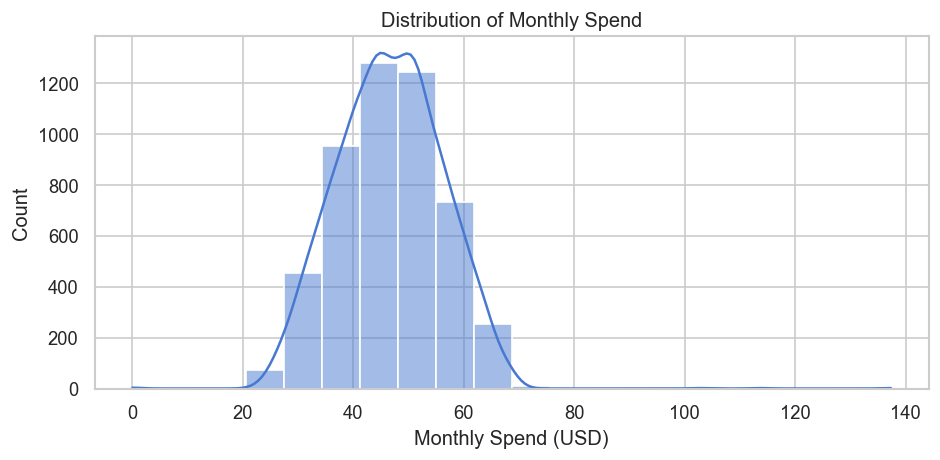

count    5000.000000
mean       46.621500
std         9.513334
min         0.000000
25%        39.897500
50%        46.625000
75%        53.210000
max       137.310000
Name: Monthly_Spend, dtype: float64


In [8]:
# Distribution of Monthly Spend
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(streaming_df['Monthly_Spend'], bins=20, kde=True, ax=ax)
ax.set_title('Distribution of Monthly Spend')
ax.set_xlabel('Monthly Spend (USD)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('spend_histogram.png', dpi=300, bbox_inches='tight') # save plot
plt.show()

print(streaming_df['Monthly_Spend'].describe())

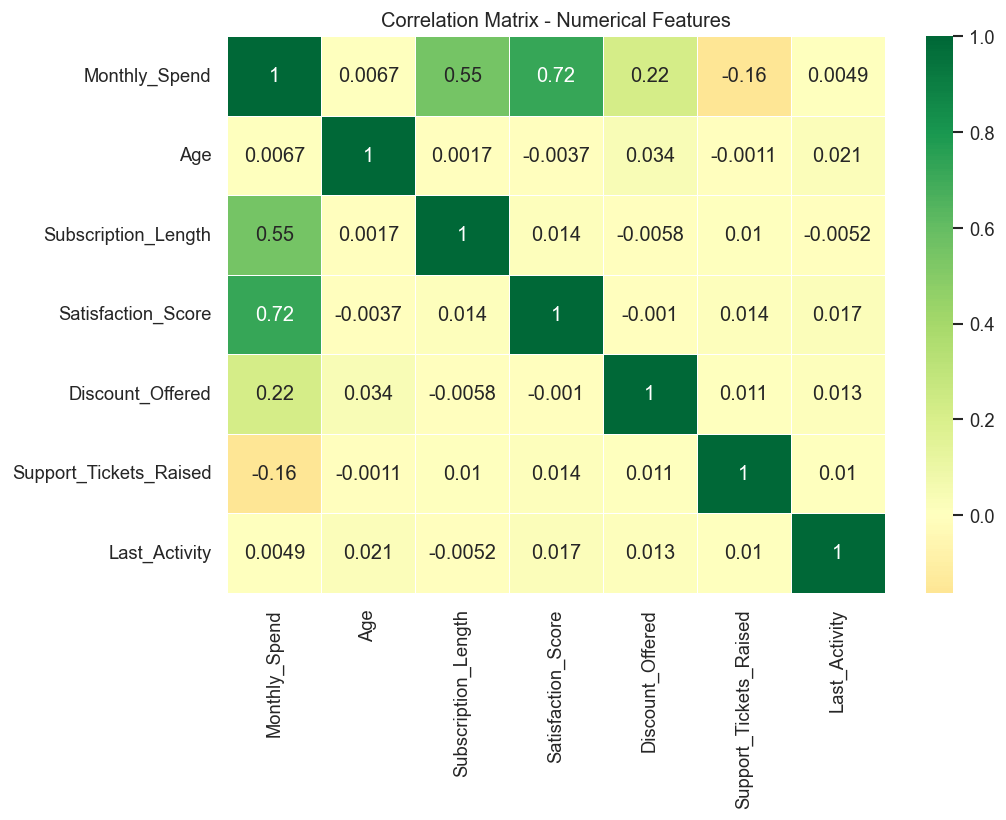

In [9]:
# Correlation matrix for numerical features
numerical_cols = ['Monthly_Spend', 'Age', 'Subscription_Length',
                  'Satisfaction_Score', 'Discount_Offered',
                  'Support_Tickets_Raised', 'Last_Activity']

corr = streaming_df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, 
            # fmt='.2f', 
            cmap='RdYlGn', 
            center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight') # save plot
plt.show()

Five of the numerical variables in the dataset have positive correlations with `Monthly Spend` with some of them being negligible - `Last Activity` & `Age`. `Discount` has a very weak correlation with `Monthly Spend` while `Subscription Length` is moderately correlated. The strongest correlation is seen between `Monthly Spend` and `Satisfaction Score`, with a positive correlation score of 0.72.

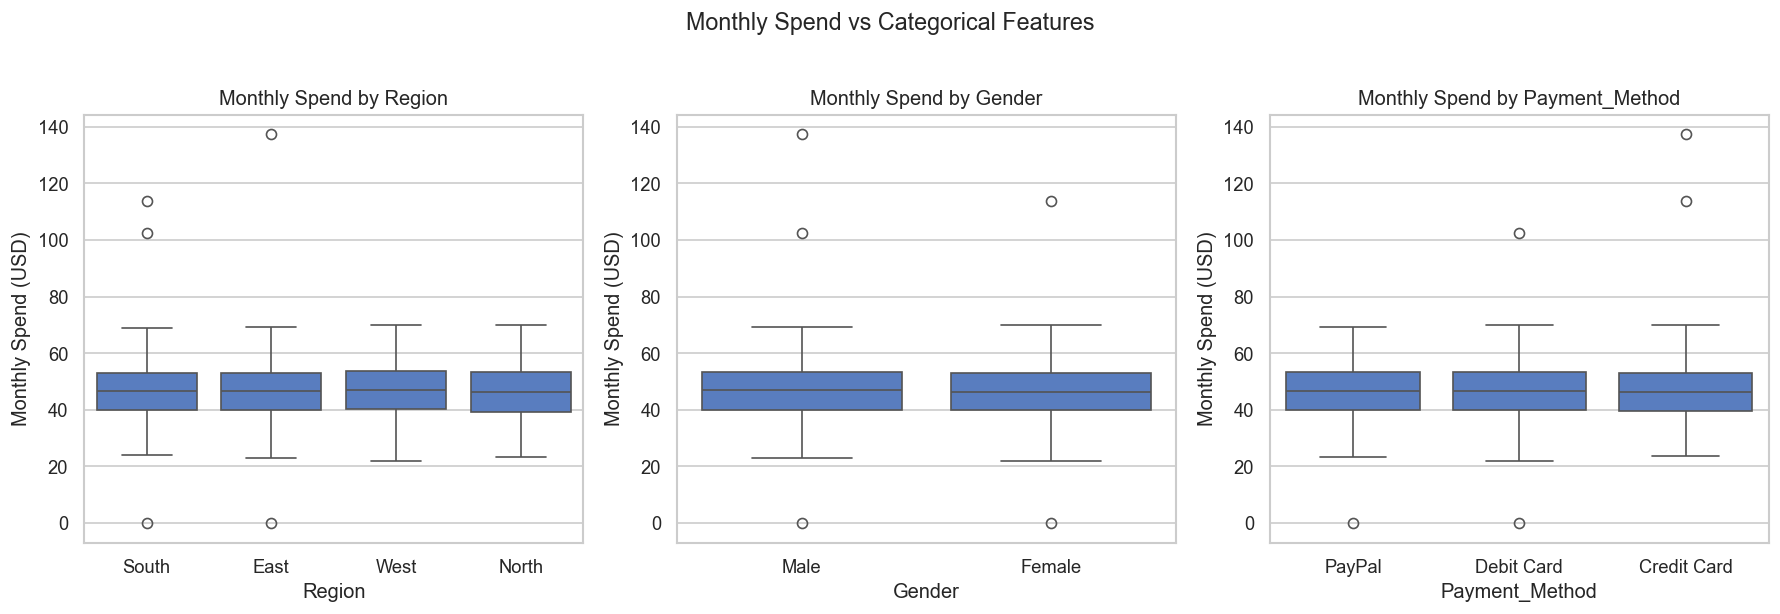

In [10]:
# Monthly Spend vs categorical features
categorical_cols = ['Region', 'Gender', 'Payment_Method']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, categorical_cols):
    sns.boxplot(data=streaming_df, x=col, y='Monthly_Spend', ax=ax)
    ax.set_title(f'Monthly Spend by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Monthly Spend (USD)')

plt.suptitle('Monthly Spend vs Categorical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('spend_categorical_box.png', dpi=300, bbox_inches='tight') # save plot
plt.show()

**Key observations from EDA:**
- Monthly spending ranges from \\$0 to ~\\$137, with a near-normal distribution centred around \$50.
- `Satisfaction_Score` has the strongest positive correlation with `Monthly_Spend` (r = 0.72).
- `Subscription_Length` shows moderate correlation (r = 0.55).
- `Age` and `Last_Activity` are essentially uncorrelated with spend.
- Spending distributions are broadly similar across regions, genders and payment methods.

## Regression: Predicting Monthly Spend

Build regression models of increasing complexity and compare their performance using R², MAE and RMSE. 

In [11]:
# Helper function: evaluate regression model and return metrics as a dictionary
def regression_metrics(y_true, y_pred, model_name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'[{model_name}]  R²: {r2:.4f}  |  MAE: {mae:.4f}  |  RMSE: {rmse:.4f}')
    return {'Model': model_name, 'R2': round(r2, 4),
            'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}


# Collect all results for the final comparison table
regression_results = []

### Univariate Linear Regression

Train a separate linear regression model for each numerical feature and identify the single best predictor of monthly spend.

In [12]:
predictor_cols = ['Age', 'Subscription_Length', 'Satisfaction_Score',
                  'Discount_Offered', 'Support_Tickets_Raised', 'Last_Activity']

target = streaming_df['Monthly_Spend']
univariate_results = [] # empty dictionary to save results

for col in predictor_cols:
    X = streaming_df[[col]].values # input feature
    y = target.values # output feature
    
    # Splitting the x and y arrays between the train and test sets. 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

    # Create an instance of the StandardScaler class
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train) 
    X_test_sc  = scaler.transform(X_test) 

    # Create an instance of the model.
    model = LinearRegression()
    # Fit the model to the training data. 
    model.fit(X_train_sc, y_train)
    # Use the final, trained model to predict the monthly spend for users in the testing dataset. 
    y_pred = model.predict(X_test_sc)

    metrics = regression_metrics(y_test, y_pred, model_name=f'Linear ({col})')
    univariate_results.append(metrics)

# sort the model results by R² scores
pd.DataFrame(univariate_results).sort_values('R2', ascending=False).reset_index(drop=True)

[Linear (Age)]  R²: -0.0009  |  MAE: 7.6414  |  RMSE: 9.5121
[Linear (Subscription_Length)]  R²: 0.2829  |  MAE: 6.6428  |  RMSE: 8.0516
[Linear (Satisfaction_Score)]  R²: 0.5330  |  MAE: 5.1736  |  RMSE: 6.4974
[Linear (Discount_Offered)]  R²: 0.0446  |  MAE: 7.4211  |  RMSE: 9.2934
[Linear (Support_Tickets_Raised)]  R²: 0.0178  |  MAE: 7.6002  |  RMSE: 9.4231
[Linear (Last_Activity)]  R²: -0.0010  |  MAE: 7.6419  |  RMSE: 9.5126


,Model,R2,MAE,RMSE
0,Linear (Satisfaction_Score),0.5330,5.1736,6.4974
1,Linear (Subscription_Length),0.2829,6.6428,8.0516
2,Linear (Discount_Offered),0.0446,7.4211,9.2934
3,Linear (Support_Tickets_Raised),0.0178,7.6002,9.4231
4,Linear (Age),-0.0009,7.6414,9.5121
5,Linear (Last_Activity),-0.0010,7.6419,9.5126


Comparing the regression models, the best Predictor is `Satisfaction Score`.

- **Lowest error values**: It has the lowest MAE and RMSE, this means that it predicts `Monthly Spend` more accurately than the others.
- **Highest R2 score (0.533)**: This means approximately 53.3% of the variance in `Monthly Spend` can be explained by `Satisfaction Score` alone.
- A higher R2 indicates a stronger linear relationship between the predictor and the target variable.

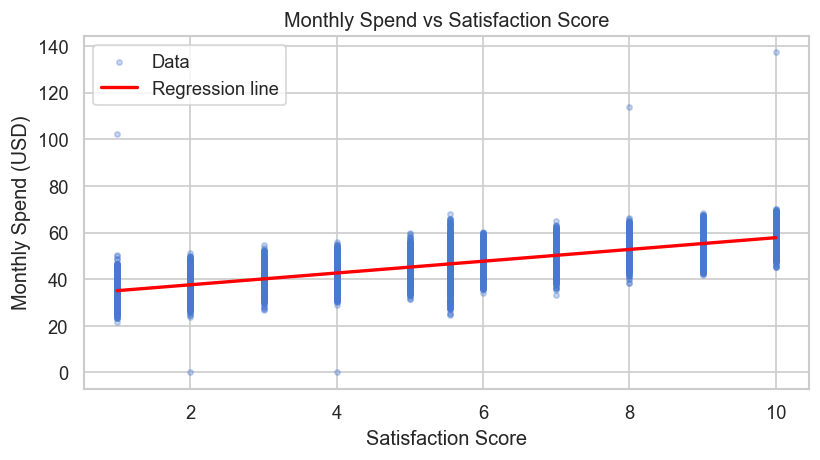

In [13]:
# Visualise the best univariate model: Satisfaction Score
best_col = 'Satisfaction_Score'
X = streaming_df[[best_col]].values
y = target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
model  = LinearRegression()
model.fit(scaler.fit_transform(X_train), y_train)

# Plot raw data + regression line
x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line  = model.predict(scaler.transform(x_range))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(streaming_df[best_col], target, alpha=0.3, s=10, label='Data')
ax.plot(x_range, y_line, color='red', linewidth=2, label='Regression line')
ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Monthly Spend (USD)')
ax.set_title('Monthly Spend vs Satisfaction Score')
ax.legend()
plt.tight_layout()
plt.savefig('spend_satisfaction.png', dpi=300, bbox_inches='tight') # save plot
plt.show()

### Polynomial Regression

Test whether a non-linear (polynomial) model captures additional variance over the linear baseline model.

In [14]:
for degree in [2, 3]:
    X = streaming_df[['Satisfaction_Score']].values
    y = target.values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

    poly    = PolynomialFeatures(degree=degree, include_bias=False)
    scaler  = StandardScaler()
    model   = LinearRegression()

    X_train_p = scaler.fit_transform(poly.fit_transform(X_train))
    X_test_p  = scaler.transform(poly.transform(X_test))

    model.fit(X_train_p, y_train)
    y_pred = model.predict(X_test_p)

    regression_metrics(y_test, y_pred, model_name=f'Polynomial degree={degree} (Satisfaction)')

[Polynomial degree=2 (Satisfaction)]  R²: 0.5330  |  MAE: 5.1737  |  RMSE: 6.4977
[Polynomial degree=3 (Satisfaction)]  R²: 0.5329  |  MAE: 5.1743  |  RMSE: 6.4984


Based on the results of the polynomial (non-linear) models applied, Monthly Spend is better modeled using a linear regression, as the data does not exhibit a clear curved or non-linear pattern. The relationship between each numerical feature and Monthly Spend appears to be predominantly linear, with minimal improvement or justification for using non-linear models.

### Multivariate Linear Regression

Using all numerical features together to improve prediction accuracy.

[Multivariate Linear]  R²: 0.8862  |  MAE: 1.3696  |  RMSE: 3.2078


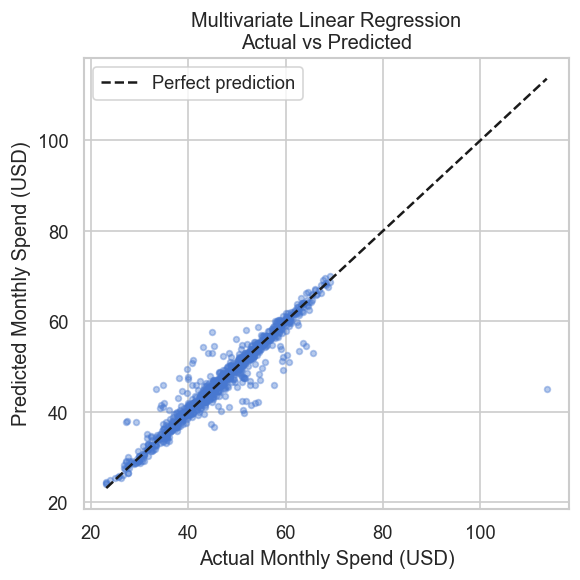

In [15]:
feature_cols = ['Subscription_Length', 'Satisfaction_Score', 'Discount_Offered', 'Support_Tickets_Raised', 'Last_Activity', 'Age']

X = streaming_df[feature_cols].values
y = target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
model  = LinearRegression()
model.fit(scaler.fit_transform(X_train), y_train)

y_pred = model.predict(scaler.transform(X_test))
mv_metrics = regression_metrics(y_test, y_pred, model_name='Multivariate Linear')
regression_results.append(mv_metrics)

# Actual vs predicted plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, alpha=0.4, s=12)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Monthly Spend (USD)')
ax.set_ylabel('Predicted Monthly Spend (USD)')
ax.set_title('Multivariate Linear Regression\nActual vs Predicted')
ax.legend()
plt.tight_layout()
plt.savefig('multivariate_linear.png', dpi=300, bbox_inches='tight') # save plot
plt.show()

### Random Forest Regression

Extend the model to include categorical features (encoded) alongside all numerical features, then test the effect of using `Region` as the sole categorical predictor.

In [16]:
# Encode categorical columns
df_encoded = streaming_df.copy()
for col in ['Region', 'Gender', 'Payment_Method']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Model A: all numerical + all categorical
all_features = feature_cols + ['Region', 'Gender', 'Payment_Method']
X_all = df_encoded[all_features].values
y = df_encoded['Monthly_Spend'].values

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=RANDOM_STATE)

rf_all = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)
rf_all_metrics = regression_metrics(y_test, y_pred_all, model_name='Random Forest (all features)')
regression_results.append(rf_all_metrics)

# Model B: all numerical + Region only
region_features = feature_cols + ['Region']
X_reg = df_encoded[region_features].values

X_train, X_test, y_train, y_test = train_test_split(X_reg, y, test_size=0.2, random_state=RANDOM_STATE)

rf_region = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_region.fit(X_train, y_train)
y_pred_reg = rf_region.predict(X_test)
rf_region_metrics = regression_metrics(y_test, y_pred_reg, model_name='Random Forest (numerical + Region)')
regression_results.append(rf_region_metrics)

[Random Forest (all features)]  R²: 0.8676  |  MAE: 1.7619  |  RMSE: 3.4591
[Random Forest (numerical + Region)]  R²: 0.8687  |  MAE: 1.7474  |  RMSE: 3.4451


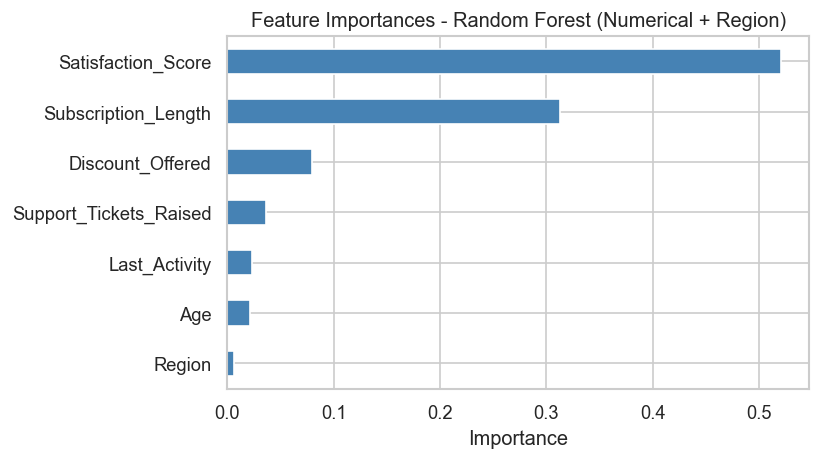

In [17]:
# Feature importances for the best Random Forest model
importances = pd.Series(rf_region.feature_importances_, index=region_features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances - Random Forest (Numerical + Region)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300, bbox_inches='tight')
plt.show()

### Artificial Neural Network (ANN)

A feed-forward neural network trained on all numerical features with early stopping to prevent overfitting.

In [18]:
X = streaming_df[feature_cols].values
y = streaming_df['Monthly_Spend'].values

# split between train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Build the ANN
tf.random.set_seed(RANDOM_STATE)
ann = keras.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear'),], 
                       name='spend_predictor')

ann.compile(
    optimizer=keras.optimizers.Adam(),
    loss='mse',
    metrics=['mae'])

ann.summary()

Model: "spend_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=20,
    restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=200,
    callbacks=[early_stop],
    verbose=0)

print(f'Training stopped at epoch {len(history.history["loss"])}')

Epoch 55: early stopping
Restoring model weights from the end of the best epoch: 35.
Training stopped at epoch 55


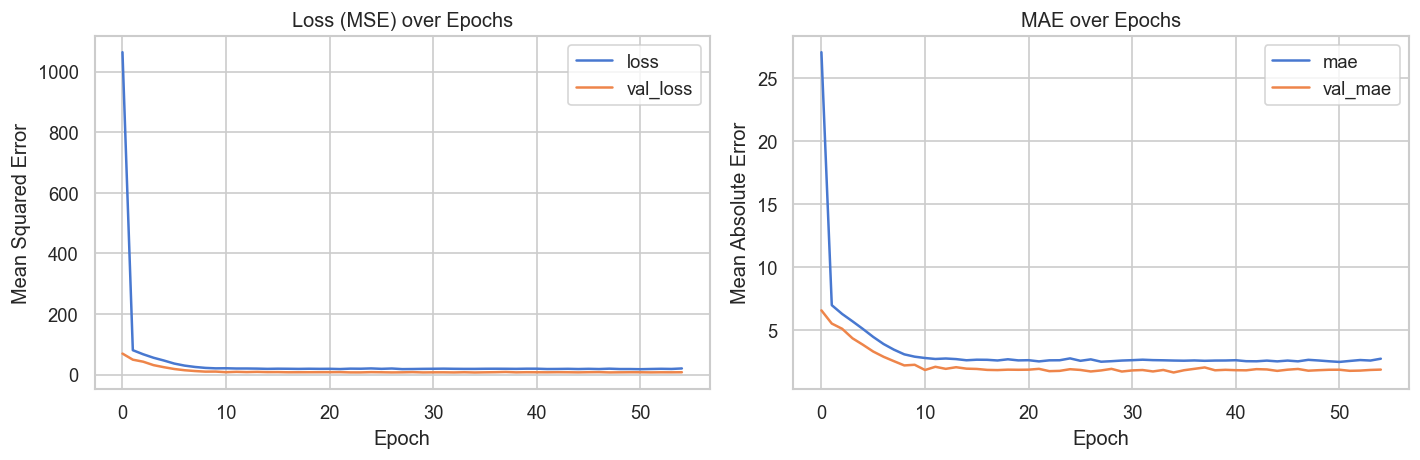

In [20]:
# Training curves
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hist_df[['loss', 'val_loss']].plot(ax=axes[0])
axes[0].set_title('Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')

hist_df[['mae', 'val_mae']].plot(ax=axes[1])
axes[1].set_title('MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step
[ANN]  R²: 0.8775  |  MAE: 1.6345  |  RMSE: 3.3272


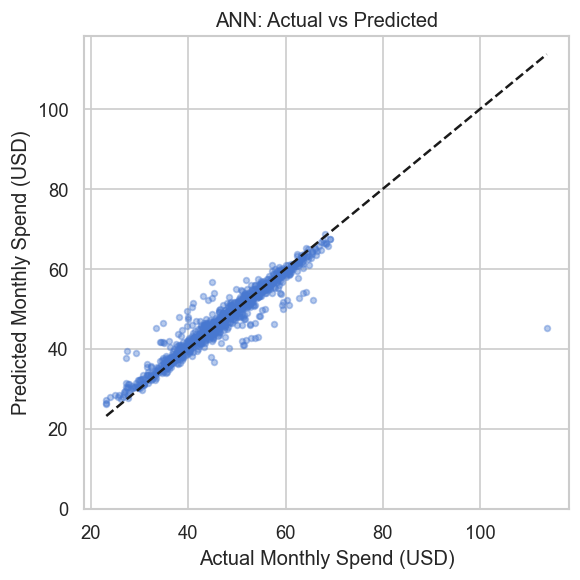

In [21]:
y_pred_ann   = ann.predict(X_test_sc).flatten()
ann_metrics  = regression_metrics(y_test, y_pred_ann, model_name='ANN')
regression_results.append(ann_metrics)

# Actual vs predicted
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_ann, alpha=0.4, s=12)
lims = [min(y_test.min(), y_pred_ann.min()), max(y_test.max(), y_pred_ann.max())]
ax.plot(lims, lims, 'k--', linewidth=1.5)
ax.set_xlabel('Actual Monthly Spend (USD)')
ax.set_ylabel('Predicted Monthly Spend (USD)')
ax.set_ylim(bottom=0)
ax.set_title('ANN: Actual vs Predicted')
plt.tight_layout()
plt.savefig('ann_actual_predicted.png', dpi=300, bbox_inches = 'tight')
plt.show()

## Classification: Predicting Customer Churn

Train three classifiers to predict whether a customer will churn (`Churned = 1`) and compare them on accuracy, F1-score and AUC-ROC.

In [22]:
# Prepare features and target
churn_features = feature_cols + ['Region', 'Gender', 'Payment_Method']
X_churn = df_encoded[churn_features].values
y_churn = df_encoded['Churned'].values

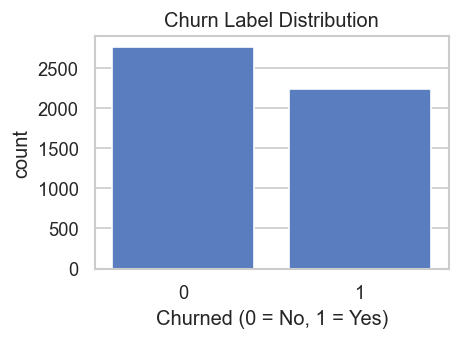

Churn rate: 44.8%


In [23]:
# Check class balance
fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x=y_churn, ax=ax)
ax.set_title('Churn Label Distribution')
ax.set_xlabel('Churned (0 = No, 1 = Yes)')
plt.tight_layout()
plt.savefig('churn_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Churn rate: {y_churn.mean():.1%}')

In [24]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=RANDOM_STATE, stratify=y_churn)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Apply SMOTE only to the SCALED training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_sc, y_train)

print(f'Original Train size: {len(y_train)} rows')
print(f'Resampled Train size: {len(y_train_resampled)} rows')
print(f'Resampled Churn rate: {y_train_resampled.mean():.1%}')

Original Train size: 4000 rows
Resampled Train size: 4416 rows
Resampled Churn rate: 50.0%



 K-Nearest Neighbours: 
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.88       552
       Churn       0.88      0.79      0.83       448

    accuracy                           0.86      1000
   macro avg       0.86      0.85      0.85      1000
weighted avg       0.86      0.86      0.86      1000

AUC-ROC: 0.9274


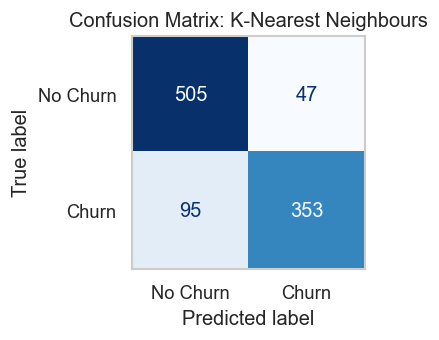


 Random Forest: 
              precision    recall  f1-score   support

    No Churn       0.96      1.00      0.98       552
       Churn       1.00      0.96      0.98       448

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

AUC-ROC: 0.9976


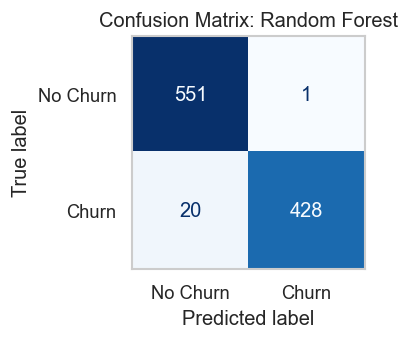


 Logistic Regression: 
              precision    recall  f1-score   support

    No Churn       0.82      0.84      0.83       552
       Churn       0.79      0.78      0.79       448

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000

AUC-ROC: 0.8945


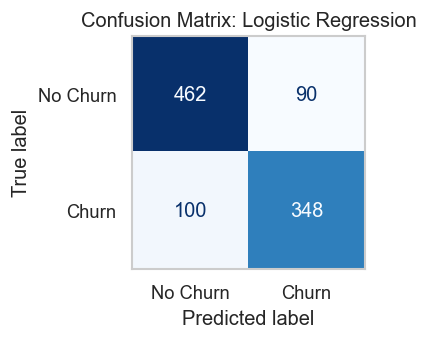

In [25]:

classifiers = {
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),}

for name, clf in classifiers.items():
    # Train models on the balanced, resampled training data
    clf.fit(X_train_sc, y_train)

    # Evaluate models using the original, un-sampled scaled test data
    y_pred  = clf.predict(X_test_sc)
    y_proba = clf.predict_proba(X_test_sc)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    print(f'\n {name}: ')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f'AUC-ROC: {auc:.4f}')

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(
        ax=ax, 
        colorbar=False, 
        cmap='Blues'
    )
    ax.grid(False) 
    ax.set_title(f'Confusion Matrix: {name}')
    plt.tight_layout()
    plt.savefig(f'Confusion Matrix_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()

**Key finding:** The Random Forest classifier consistently outperforms the others, achieving 98% accuracy and an AUC-ROC of ~0.99 — indicating a very high rate of true positives with few false positives.

## Clustering: Discovering Customer Segments

Use unsupervised learning to identify natural groupings in customer behaviour, independently of churn labels.

### k-Means Clustering

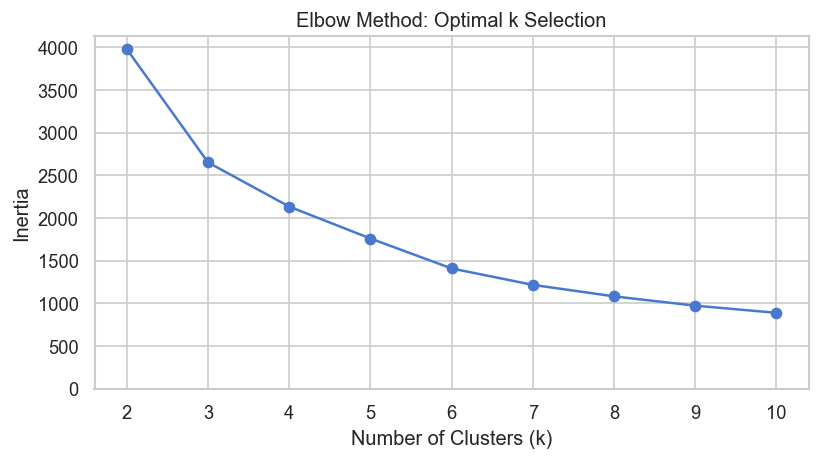

In [26]:
# Determine the optimal number of clusters using the elbow method
cluster_features = streaming_df[['Satisfaction_Score', 'Monthly_Spend']].values
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(cluster_features)

inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o')
ax.set_ylim(bottom=0)
ax.set_title('Elbow Method: Optimal k Selection')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('optimal_k.png', dpi=300, bbox_inches='tight')
plt.show()

kMeans  |  Silhouette: 0.4078  |  Davies-Bouldin: 0.8347


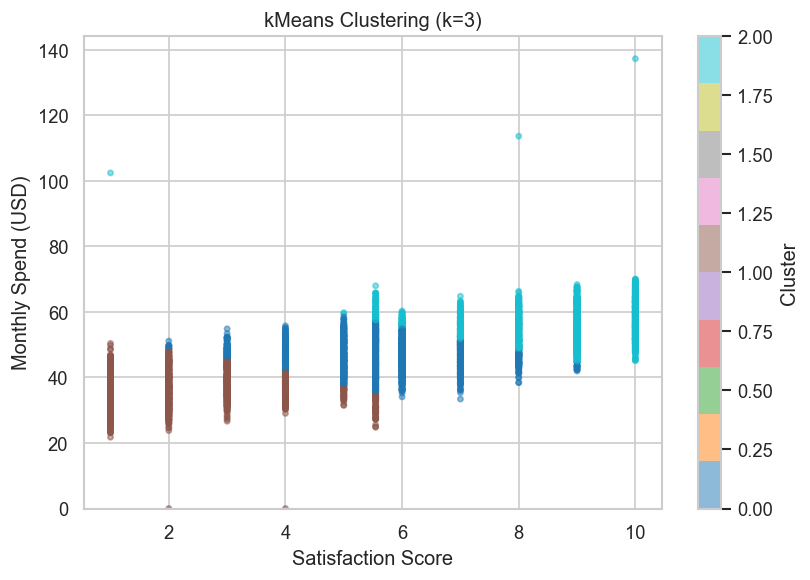

In [27]:
# Fit kMeans with k=3 and evaluate
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X_cl)

sil_km = silhouette_score(X_cl, km_labels)
db_km  = davies_bouldin_score(X_cl, km_labels)
print(f'kMeans  |  Silhouette: {sil_km:.4f}  |  Davies-Bouldin: {db_km:.4f}')

# Visualise clusters
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    streaming_df['Satisfaction_Score'],
    streaming_df['Monthly_Spend'],
    c=km_labels, cmap='tab10', alpha=0.5, s=10)

ax.set_xlabel('Satisfaction Score')
ax.set_ylabel('Monthly Spend (USD)')
ax.set_ylim(bottom=0)
ax.set_title(f'kMeans Clustering (k={k_opt})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('kMeans_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

### Agglomerative (Hierarchical) Clustering
Compare k-Means against Agglomerative clustering across three feature pairs.

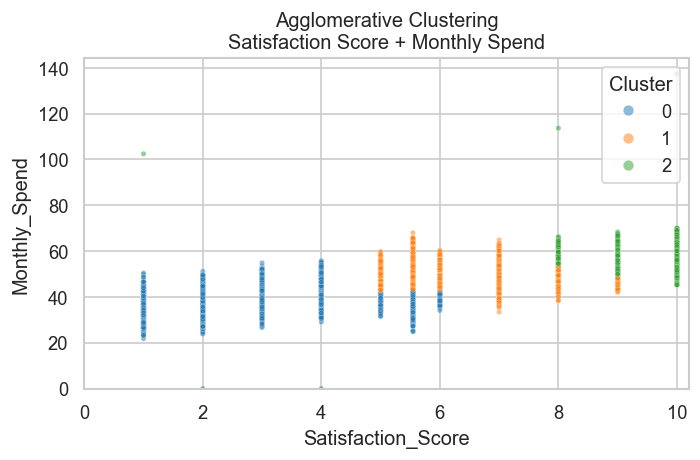

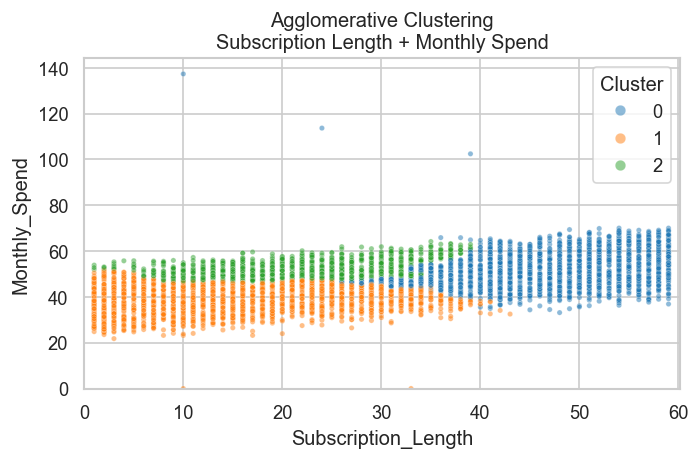

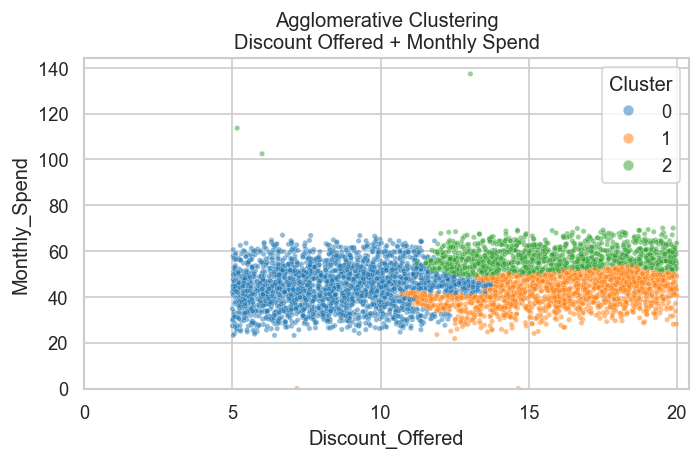

,Feature Pair,Algorithm,Silhouette,Davies-Bouldin
0,Satisfaction Score + Monthly Spend,k-Means,0.4078,0.8347
1,Satisfaction Score + Monthly Spend,Agglomerative,0.3834,0.8646
2,Subscription Length + Monthly Spend,Agglomerative,0.3446,0.9357
3,Discount Offered + Monthly Spend,Agglomerative,0.3262,0.9582


In [28]:
cluster_pairs = {
    'Satisfaction Score + Monthly Spend': ['Satisfaction_Score', 'Monthly_Spend'],
    'Subscription Length + Monthly Spend': ['Subscription_Length', 'Monthly_Spend'],
    'Discount Offered + Monthly Spend':   ['Discount_Offered', 'Monthly_Spend'],
}

# Define uniform tick spacing per feature
x_tick_spacing = {
    'Satisfaction_Score': 2,
    'Subscription_Length': 10,
    'Discount_Offered': 5,
}

clustering_results = []

for label, cols in cluster_pairs.items():
    X_pair = StandardScaler().fit_transform(streaming_df[cols].values)

    agg  = AgglomerativeClustering(n_clusters=3)
    pred = agg.fit_predict(X_pair)

    sil = silhouette_score(X_pair, pred)
    db  = davies_bouldin_score(X_pair, pred)
    clustering_results.append(
        {'Feature Pair': label, 'Algorithm': 'Agglomerative',
         'Silhouette': round(sil, 4), 'Davies-Bouldin': round(db, 4)})

    fig, ax = plt.subplots(figsize=(6, 4))
    
    sns.scatterplot(
        data=streaming_df,
        x=cols[0],
        y=cols[1],
        hue=pred,
        palette='tab10',
        alpha=0.5,
        s=10,
        ax=ax,
        legend='full')
    
    #  Legend: inside upper-right 
    ax.legend(
        title='Cluster',
        loc='upper right',
        framealpha=0.8,
        markerscale=2
    )
    # X-axis
    x_min = streaming_df[cols[0]].min()
    x_max = streaming_df[cols[0]].max()
    ax.set_xlim(left=0, right=x_max * 1.02)   
    ax.margins(x=0)

    # Y-axis: start at 0 
    ax.set_ylim(bottom=0)

    # Uniform tick spacing
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_spacing[cols[0]]))
    ax.yaxis.set_major_locator(MultipleLocator(20)) 

    ax.set_title(f'Agglomerative Clustering\n{label}')
    plt.tight_layout()
    plt.savefig(f'agglomerative_{label.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Add k-Means baseline
clustering_results.insert(0, {
    'Feature Pair': 'Satisfaction Score + Monthly Spend',
    'Algorithm': 'k-Means',
    'Silhouette': round(sil_km, 4),
    'Davies-Bouldin': round(db_km, 4)
})

pd.DataFrame(clustering_results)


## Summary of Results

### Regression Model Comparison

In [29]:
# Add the best univariate baseline for reference
univariate_best = {
    'Model': 'Linear (Satisfaction Score only)',
    'R2': 0.533, 'MAE': 5.1736, 'RMSE': 6.4974
}
summary = pd.DataFrame([univariate_best] + regression_results)
summary = summary.sort_values('R2', ascending=False).reset_index(drop=True)
summary

,Model,R2,MAE,RMSE
0,Multivariate Linear,0.8862,1.3696,3.2078
1,ANN,0.8775,1.6345,3.3272
2,Random Forest (numerical + Region),0.8687,1.7474,3.4451
3,Random Forest (all features),0.8676,1.7619,3.4591
4,Linear (Satisfaction Score only),0.5330,5.1736,6.4974


### Conclusions

| Task | Best Model | Key Metric |
|------|-----------|------------|
| Regression | Random Forest (Numerical + Region) | R² = 0.87 |
| Classification | Random Forest Classifier | AUC-ROC ≈ 0.975 |
| Clustering | Agglomerative (Subscription Length + Spend) | Silhouette = 0.63 |

**Regression insights:**
- Satisfaction Score is by the most informative single predictor (R² = 0.53).
- Adding all numerical variables lifts R² to 0.86; appending the Region variable further improves it to ~0.87.
- The ANN (R² ≈ 0.875) performs well but does not surpass the best linear model on this dataset.

**Classification insights:**
- The Random Forest classifier correctly identifies 98% of customers, with an AUC-ROC of ~0.99.
- Logistic Regression (AUC ~0.81) is the weakest classifier, suggesting non-linear decision boundaries are important.

**Clustering insights:**
- Three customer segments emerge consistently across methods.
- Subscription Length is a more discriminating clustering feature than Satisfaction Score or Discount Offered.

_The End_